# 💳 Customer Credit Card Clustering — ML Pipeline

| | |
|---|---|
| **Nama** | Rangga Timotius |
| **NIM** | 101032300137 |
| **Kelas** | TK46GAB |

---
## 📌 Deskripsi Proyek
Dataset berisi informasi perilaku penggunaan kartu kredit dari **8.950 pelanggan**.  
**Tujuan:** mengelompokkan pelanggan berdasarkan pola pengeluaran dan pembayaran mereka menggunakan metode *unsupervised learning*.

## 🗂️ Alur Pipeline
1. Import Library → 2. Load & EDA → 3. Preprocessing → 4. Menentukan Jumlah Cluster → 5. Model Training (K-Means, Hierarchical, DBSCAN) → 6. Evaluasi & Perbandingan → 7. Profiling Cluster → 8. Kesimpulan


## 1. 📦 Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


## 2. 📂 Load & Eksplorasi Data (EDA)

In [ ]:
df = pd.read_csv('clusteringmidterm.csv')
print(f"Shape dataset : {df.shape}")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
df.head()

Shape dataset : (8950, 18)
Jumlah baris  : 8,950
Jumlah kolom  : 18


In [ ]:
print("=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()} dari {df.shape[0]*df.shape[1]:,} nilai")

=== Missing Values ===
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313

Total missing: 314 dari 161,100 nilai


In [ ]:
print(df.describe().T[['mean','std','min','max']].round(2).to_string())

                                     mean      std    min       max
BALANCE                           1517.85  1882.59   0.00   7831.71
BALANCE_FREQUENCY                    0.91     0.16   0.56      1.00
PURCHASES                          838.83  1144.16   0.00   4321.62
ONEOFF_PURCHASES                   427.67   688.29   0.00   2309.62
INSTALLMENTS_PURCHASES             342.24   515.00   0.00   1874.55
CASH_ADVANCE                       807.18  1321.23   0.00   4455.28
PURCHASES_FREQUENCY                  0.49     0.40   0.00      1.00
ONEOFF_PURCHASES_FREQUENCY           0.20     0.30   0.00      1.00
PURCHASES_INSTALLMENTS_FREQUENCY     0.36     0.40   0.00      1.00
CASH_ADVANCE_FREQUENCY               0.13     0.20   0.00      0.89
CASH_ADVANCE_TRX                     2.78     4.43   0.00     16.00
PURCHASES_TRX                       13.04    16.77   0.00     65.00
CREDIT_LIMIT                      4490.43  3617.43  50.00  21200.00
PAYMENTS                          1494.05  1651.

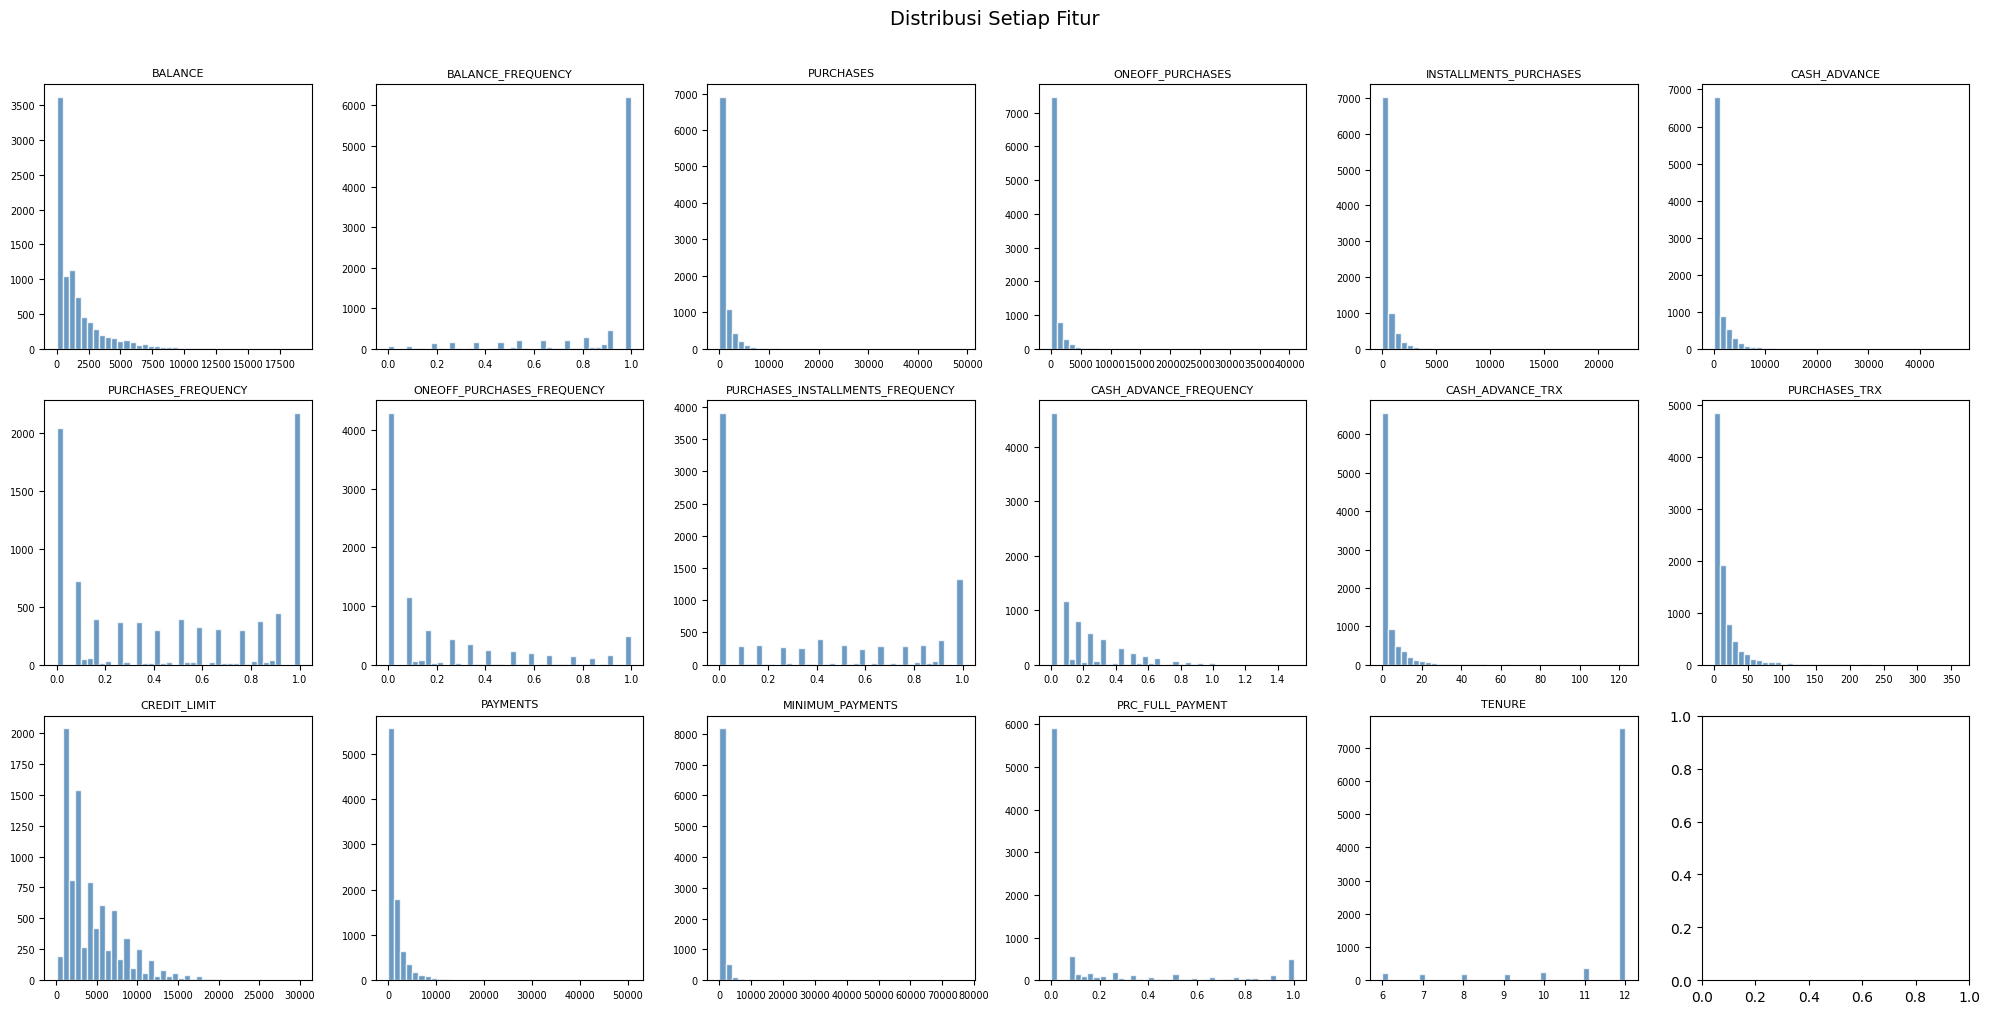

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
axes = axes.flatten()
num_cols = df.drop(columns=['CUST_ID']).columns
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)
plt.suptitle('Distribusi Setiap Fitur', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

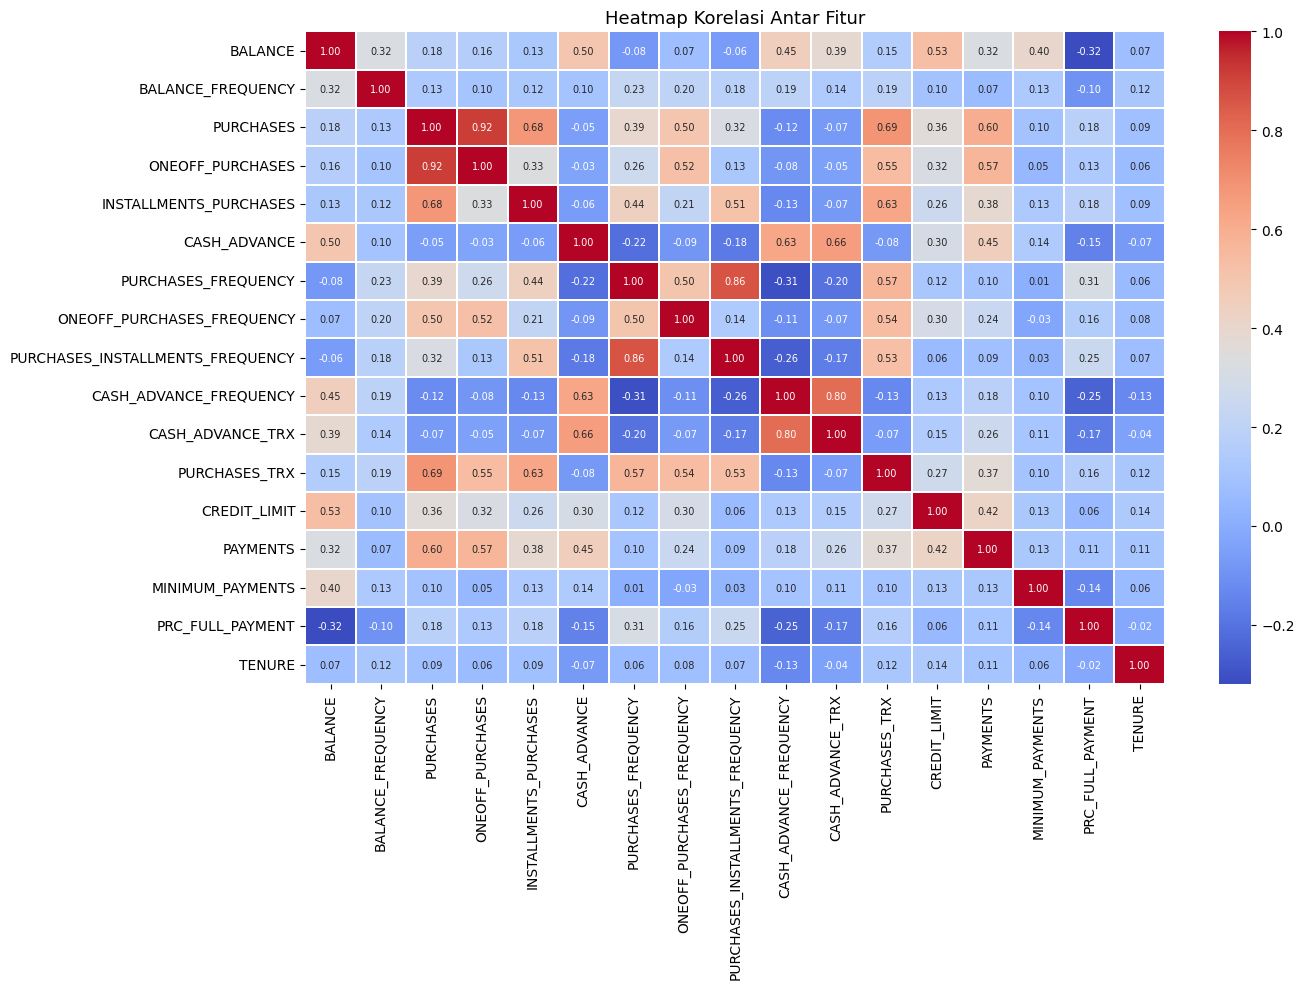

In [ ]:
plt.figure(figsize=(14, 10))
corr = df.drop(columns=['CUST_ID']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.3, annot_kws={'size':7})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13)
plt.tight_layout()
plt.show()

## 3. 🔧 Preprocessing

In [ ]:
df_work = df.drop(columns=['CUST_ID']).copy()

# Isi missing values dengan median
for col in df_work.columns:
    df_work[col] = df_work[col].fillna(df_work[col].median())

print("✅ Missing values diisi dengan median masing-masing kolom")
print(f"Missing setelah imputation: {df_work.isnull().sum().sum()}")

✅ Missing values diisi dengan median masing-masing kolom
Missing setelah imputation: 0


In [ ]:
def clip_outliers_iqr(df_in, multiplier=3.0):
    df_c = df_in.copy()
    for col in df_c.columns:
        Q1, Q3 = df_c[col].quantile(0.25), df_c[col].quantile(0.75)
        IQR = Q3 - Q1
        df_c[col] = df_c[col].clip(Q1 - multiplier*IQR, Q3 + multiplier*IQR)
    return df_c

df_clean = clip_outliers_iqr(df_work)
print("✅ Outlier handling selesai (IQR clipping, multiplier=3.0)")

✅ Outlier handling selesai (IQR clipping, multiplier=3.0)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
print("✅ Feature scaling selesai (StandardScaler)")
print(f"Shape X_scaled: {X_scaled.shape}")

✅ Feature scaling selesai (StandardScaler)
Shape X_scaled: (8950, 17)


## 4. 🔍 Menentukan Jumlah Cluster Optimal

In [ ]:
inertias, silhouettes = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"K={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.4f}")

K=2: inertia=111561, silhouette=0.2893
K=3: inertia=90001, silhouette=0.2595
K=4: inertia=78399, silhouette=0.2103
K=5: inertia=71591, silhouette=0.2071
K=6: inertia=66159, silhouette=0.2150
K=7: inertia=62546, silhouette=0.2080
K=8: inertia=59397, silhouette=0.2053
K=9: inertia=56659, silhouette=0.2082
K=10: inertia=54683, silhouette=0.2058


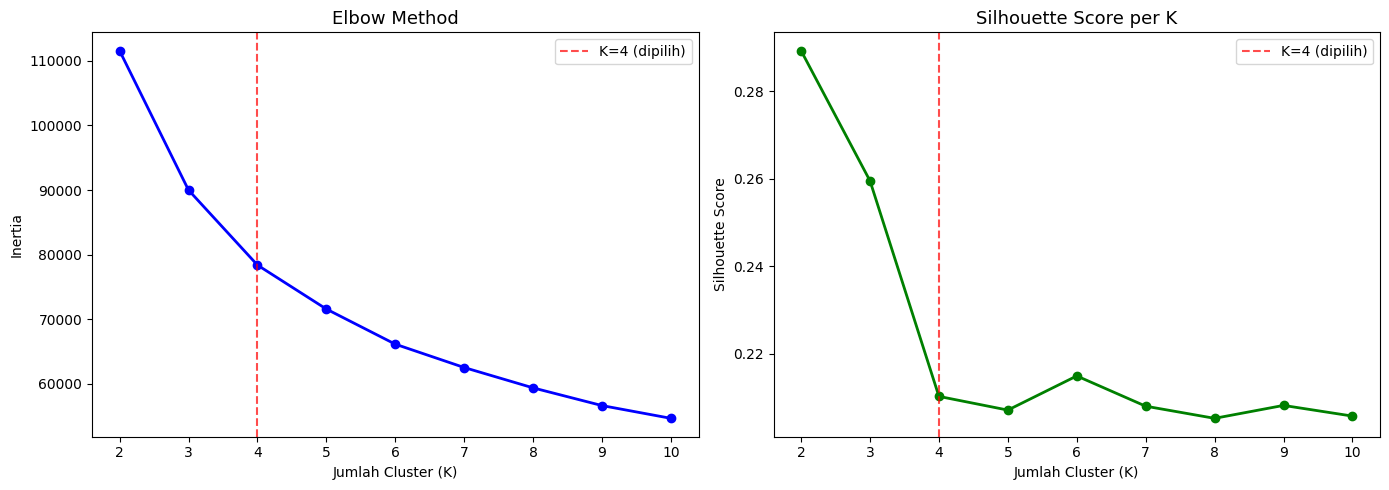

✅ K=4 dipilih berdasarkan kombinasi elbow + silhouette score


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-', lw=2)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (dipilih)')
axes[0].set_xlabel('Jumlah Cluster (K)'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontsize=13); axes[0].legend()

axes[1].plot(k_range, silhouettes, 'go-', lw=2)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (dipilih)')
axes[1].set_xlabel('Jumlah Cluster (K)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K', fontsize=13); axes[1].legend()
plt.tight_layout(); plt.show()
print("✅ K=4 dipilih berdasarkan kombinasi elbow + silhouette score")

## 5. 🤖 Model Training

### 5.1 K-Means Clustering

In [ ]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
print(f"✅ K-Means selesai")
print(f"Distribusi cluster: {dict(zip(*np.unique(km_labels, return_counts=True)))}")

✅ K-Means selesai
Distribusi cluster: {0: 2614, 1: 3624, 2: 1502, 3: 1210}


### 5.2 Hierarchical (Agglomerative) Clustering

In [ ]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled)
print(f"✅ Agglomerative Clustering selesai")
print(f"Distribusi cluster: {dict(zip(*np.unique(agg_labels, return_counts=True)))}")

✅ Agglomerative Clustering selesai
Distribusi cluster: {0: 1793, 1: 3707, 2: 1654, 3: 1796}


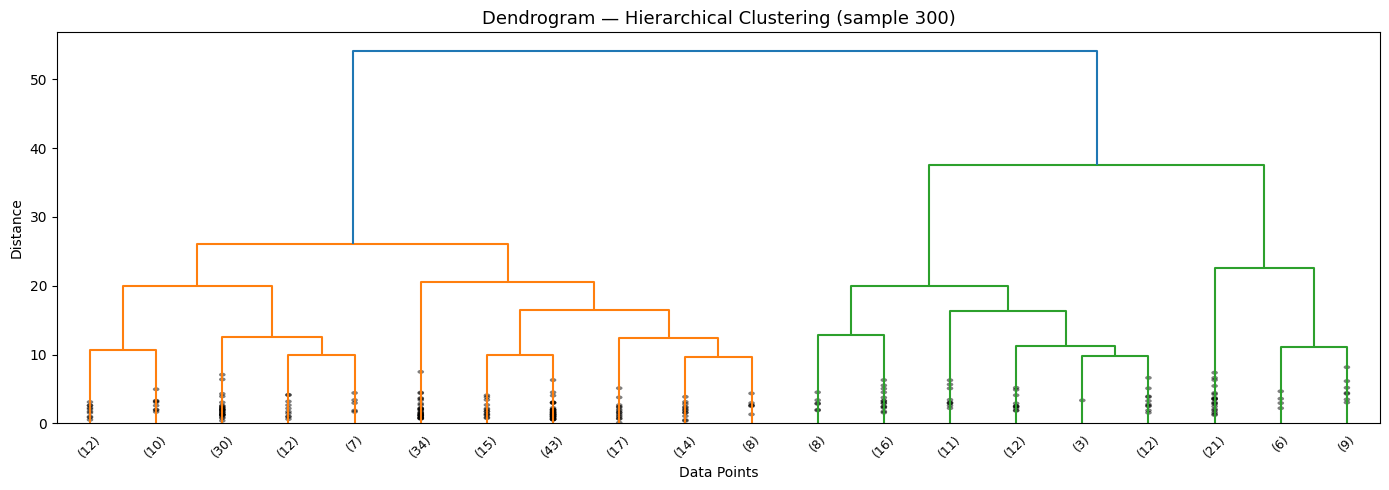

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_scaled[:300], method='ward')
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linked, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=9, show_contracted=True)
ax.set_title('Dendrogram — Hierarchical Clustering (sample 300)', fontsize=13)
ax.set_xlabel('Data Points'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()

### 5.3 DBSCAN

In [ ]:
dbs = DBSCAN(eps=2.5, min_samples=5)
dbs_labels = dbs.fit_predict(X_scaled)
n_clusters_dbs = len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)
noise = (dbs_labels == -1).sum()
print(f"✅ DBSCAN selesai")
print(f"Jumlah cluster ditemukan : {n_clusters_dbs}")
print(f"Jumlah noise points      : {noise} ({noise/len(dbs_labels)*100:.1f}%)")

✅ DBSCAN selesai
Jumlah cluster ditemukan : 3
Jumlah noise points      : 201 (2.2%)


## 6. 📊 Evaluasi & Perbandingan Model

In [ ]:
metrics = {
    'K-Means (K=4)' : {
        'Silhouette ↑': silhouette_score(X_scaled, km_labels),
        'Davies-Bouldin ↓': davies_bouldin_score(X_scaled, km_labels),
        'Calinski-Harabasz ↑': calinski_harabasz_score(X_scaled, km_labels),
    },
    'Agglomerative (K=4)': {
        'Silhouette ↑': silhouette_score(X_scaled, agg_labels),
        'Davies-Bouldin ↓': davies_bouldin_score(X_scaled, agg_labels),
        'Calinski-Harabasz ↑': calinski_harabasz_score(X_scaled, agg_labels),
    },
    'DBSCAN': {
        'Silhouette ↑': silhouette_score(X_scaled[dbs_labels!=-1], dbs_labels[dbs_labels!=-1]),
        'Davies-Bouldin ↓': None,
        'Calinski-Harabasz ↑': None,
    }
}
metrics_df = pd.DataFrame(metrics).T.round(4)
print("=== Evaluasi Model Clustering ===")
print(metrics_df.to_string())

=== Evaluasi Model Clustering ===
Model                        Silhouette ↑   Davies-Bouldin ↓    Calinski-Harabasz ↑
----------------------------------------------------------------------------------
K-Means (K=4)                      0.2103             1.5290                2464.82
Agglomerative (K=4)                0.1777             1.6907                1876.04
DBSCAN                             0.3907                N/A                    N/A


Variance explained by PC1+PC2: 57.3%


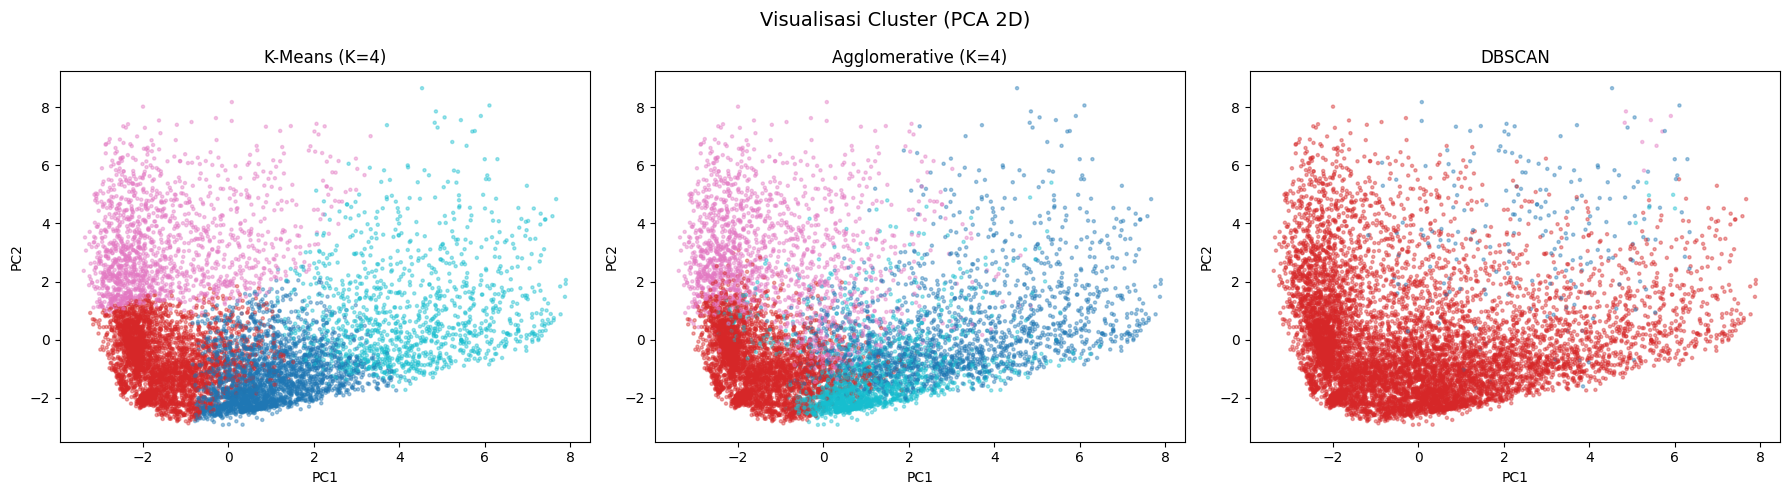

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['K-Means (K=4)', 'Agglomerative (K=4)', 'DBSCAN']
all_labels = [km_labels, agg_labels, dbs_labels]
cmaps = ['tab10', 'tab10', 'tab10']

for ax, title, lbl in zip(axes, titles, all_labels):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl, cmap='tab10', alpha=0.4, s=5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle('Visualisasi Cluster (PCA 2D)', fontsize=14)
plt.tight_layout(); plt.show()

## 7. 🧩 Profiling Cluster (K-Means)

In [ ]:
df_profiling = df_clean.copy()
df_profiling['Cluster'] = km_labels

profile = df_profiling.groupby('Cluster').mean().round(2)
key_cols = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT',
            'PAYMENTS','PRC_FULL_PAYMENT','PURCHASES_FREQUENCY','TENURE']
print("=== Profil Rata-rata Setiap Cluster ===")
print(profile[key_cols].to_string())

=== Profil Rata-rata Setiap Cluster ===
                BALANCE  PURCHASES  CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PRC_FULL_PAYMENT  PURCHASES_FREQUENCY  TENURE
KMeans_Cluster                                                                                                         
0                638.36     815.81        138.39       3513.84    939.32              0.21                 0.87    12.0
1                913.44     259.84        478.24       3209.11    845.92              0.06                 0.17    12.0
2               3913.91     355.14       3010.59       6726.33   2470.38              0.03                 0.25    12.0
3               2253.81    3223.04        502.03       7662.31   3421.70              0.19                 0.92    12.0


In [ ]:
cluster_counts = pd.Series(km_labels).value_counts().sort_index()
print("=== Ukuran Setiap Cluster ===")
for c, n in cluster_counts.items():
    print(f"  Cluster {c}: {n:,} pelanggan ({n/len(km_labels)*100:.1f}%)")

=== Ukuran Setiap Cluster ===
  Cluster 0: 2,614 pelanggan (29.2%)
  Cluster 1: 3,624 pelanggan (40.5%)
  Cluster 2: 1,502 pelanggan (16.8%)
  Cluster 3: 1,210 pelanggan (13.5%)


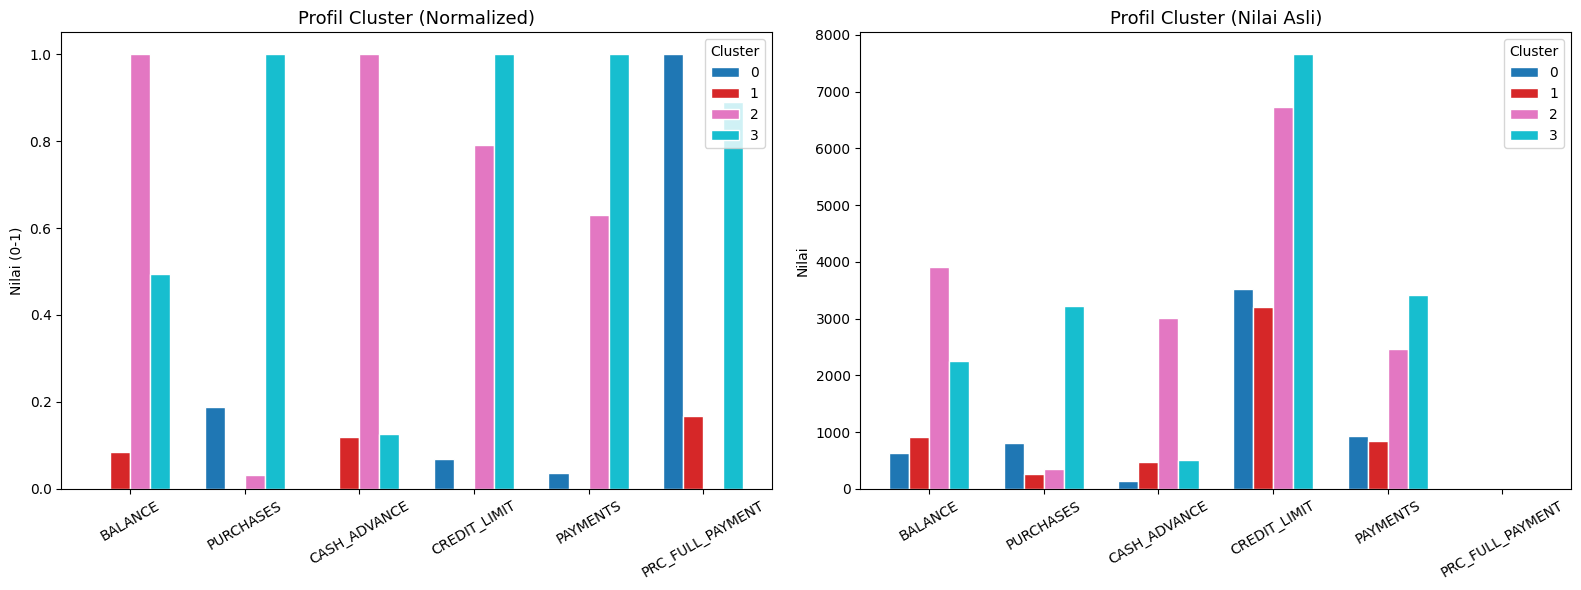

In [ ]:
key_cols = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']
profile_norm = (profile[key_cols] - profile[key_cols].min()) / (profile[key_cols].max() - profile[key_cols].min())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
profile_norm.T.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white', width=0.7)
axes[0].set_title('Profil Cluster (Normalized)', fontsize=13)
axes[0].set_ylabel('Nilai (0-1)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Cluster', loc='upper right')

profile[key_cols].T.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white', width=0.7)
axes[1].set_title('Profil Cluster (Nilai Asli)', fontsize=13)
axes[1].set_ylabel('Nilai'); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Cluster', loc='upper right')
plt.tight_layout(); plt.show()

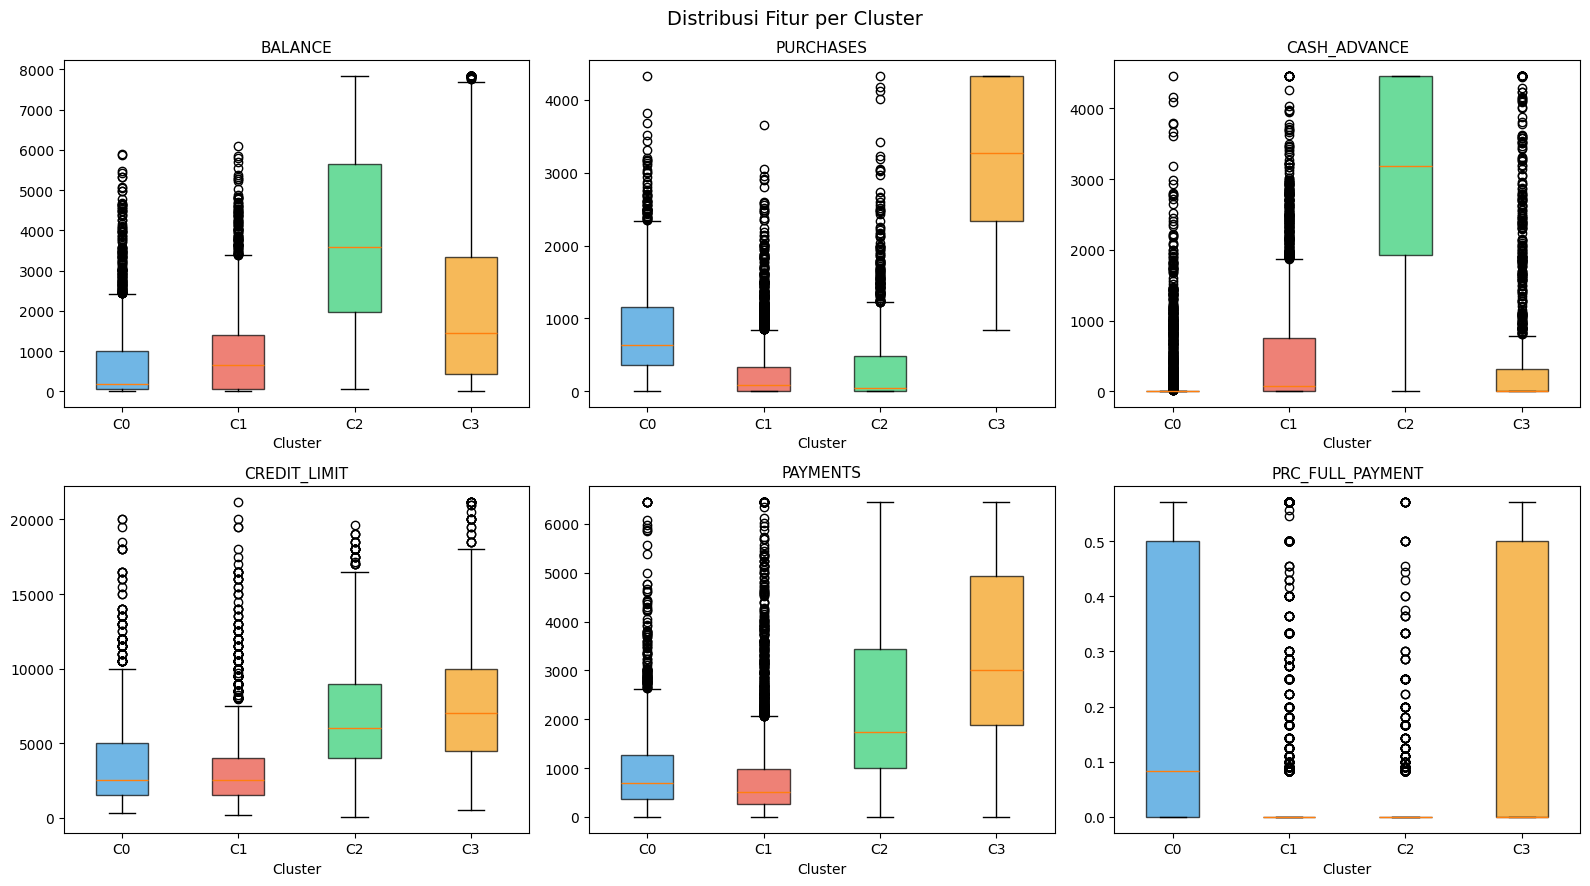

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    df_profiling.boxplot(column=col, by='Cluster', ax=axes[i],
                         patch_artist=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Cluster')
plt.suptitle('Distribusi Fitur per Cluster', fontsize=14)
plt.tight_layout(); plt.show()

## 8. 📝 Kesimpulan

### Perbandingan Model Clustering

| Model | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|---|---|---|---|
| **K-Means (K=4)** | 0.2103 | 1.5290 | 2464.82 |
| Agglomerative (K=4) | 0.1777 | 1.6907 | 1876.04 |
| DBSCAN | 0.3907 | N/A | N/A |

**→ K-Means (K=4) dipilih** sebagai model terbaik berdasarkan Calinski-Harabasz dan Davies-Bouldin score.

---

### Interpretasi Cluster (K-Means, K=4)

| Cluster | Nama Segmen | Karakteristik Utama |
|---|---|---|
| **0** | 🟢 Pengguna Aktif Moderat | Balance rendah, pembelian aktif, pembayaran rutin |
| **1** | 🔵 Pengguna Pasif / Minimum | Balance rendah, pembelian minim, sering ambil cash advance kecil |
| **2** | 🔴 Cash Advance Heavy | Balance tinggi, cash advance sangat tinggi, jarang bayar penuh |
| **3** | 🟡 Big Spender | Pembelian sangat tinggi, credit limit besar, pembayaran besar |

### Insight Bisnis
- **Cluster 2 (Cash Advance Heavy)** perlu perhatian khusus — risiko kredit tinggi karena jarang bayar penuh dan sering tarik tunai.
- **Cluster 3 (Big Spender)** adalah segmen premium yang bisa ditargetkan untuk produk/layanan eksklusif.
- **Cluster 0 (Aktif Moderat)** adalah segmen terbesar — cocok untuk program loyalitas.
- **Cluster 1 (Pasif)** perlu strategi re-engagement agar lebih aktif menggunakan kartu.

### Saran Pengembangan
- Coba **XGBoost / LightGBM** untuk supervised follow-up (prediksi churn per cluster)
- Tambahkan **feature engineering** (rasio PURCHASES/CREDIT_LIMIT, dll.)
- Eksplorasi **UMAP** untuk visualisasi yang lebih akurat dari PCA
